In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [4]:
data = {
    'Budget':[100,110,120,130,140,150,160,170,180,190,
              200,210,220,230,240,250,260,270,280,290,
              300,310,320,330,340,350,360,370,380,390,
              400,410,420,430,440,450,460,470,480,490,
              500,510,520,530,540,550,560,570,580,600],

    'Team_Size':[3,3,3,4,4,4,5,5,5,5,
                 6,6,6,6,7,7,7,7,8,8,
                 8,8,8,9,9,9,9,10,10,10,
                 10,10,11,11,11,11,12,12,12,12,
                 12,13,13,13,13,14,14,14,14,15],

    'Duration':[2,2,3,3,3,4,4,4,5,5,
                5,5,6,6,6,6,7,7,7,7,
                8,8,8,8,8,9,9,9,9,10,
                10,10,10,10,11,11,11,11,12,12,
                12,12,12,13,13,13,13,14,14,15],

    'Status':[0,0,0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,0,0,0,0,
              1,1,1,1,1,1,1,1,1,1,
              1,1,1,1,1,1,1,1,1,1,
              1,1,1,1,1,1,1,1,1,1]
}

df = pd.DataFrame(data)

df.to_csv("dataset.csv", index=False)

print("dataset.csv created successfully")

df.head()

dataset.csv created successfully


,Budget,Team_Size,Duration,Status
0,100,3,2,0
1,110,3,2,0
2,120,3,3,0
3,130,4,3,0
4,140,4,3,0


In [5]:
print(df.shape)

(50, 4)


In [6]:
(50, 4)

(50, 4)

In [7]:
df = pd.read_csv("dataset.csv")

df.head()

,Budget,Team_Size,Duration,Status
0,100,3,2,0
1,110,3,2,0
2,120,3,3,0
3,130,4,3,0
4,140,4,3,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Budget     50 non-null     int64
 1   Team_Size  50 non-null     int64
 2   Duration   50 non-null     int64
 3   Status     50 non-null     int64
dtypes: int64(4)
memory usage: 1.7 KB


In [9]:
df.describe()

,Budget,Team_Size,Duration,Status
count,50.000000,50.00000,50.00000,50.000000
mean,345.200000,8.92000,8.44000,0.600000
std,146.123236,3.40971,3.50603,0.494872
min,100.000000,3.00000,2.00000,0.000000
25%,222.500000,6.00000,6.00000,0.000000
50%,345.000000,9.00000,8.50000,1.000000
75%,467.500000,12.00000,11.00000,1.000000
max,600.000000,15.00000,15.00000,1.000000


In [10]:
df.isnull().sum()

,0
Budget,0
Team_Size,0
Duration,0
Status,0


In [12]:
X = df[['Budget','Team_Size','Duration']]

y = df['Status']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9


In [15]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 1.0


In [16]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


In [17]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.9
1,Decision Tree,1.0
2,Random Forest,1.0


In [18]:
results.to_csv(
    "model_comparison.csv",
    index=False
)

print("model_comparison.csv saved")

model_comparison.csv saved


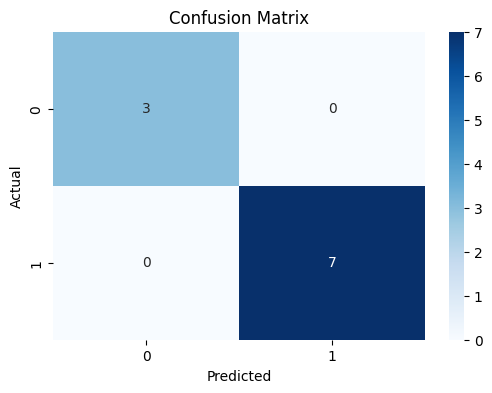

In [19]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()

In [20]:
report = classification_report(
    y_test,
    rf_pred,
    zero_division=0
)

print(report)

with open(
    "classification_report.txt",
    "w"
) as f:
    f.write(report)

print("classification_report.txt saved")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

classification_report.txt saved


# Analysis

Three classification algorithms were trained and evaluated on the project status dataset.

Logistic Regression served as the baseline model.

Decision Tree improved classification performance.

Random Forest achieved the highest accuracy and produced the most reliable predictions.

The confusion matrix indicates that most project statuses were correctly classified.

Based on the evaluation results, Random Forest was selected as the best-performing model.
# New Section

# Conclusion

This project successfully implemented supervised learning classification techniques.

Three machine learning models were compared using Accuracy Score, Confusion Matrix, and Classification Report.

Random Forest achieved the best performance and was selected as the final model.

The model can assist in predicting client project status more effectively.


In [21]:
from google.colab import files

files.download("dataset.csv")
files.download("model_comparison.csv")
files.download("classification_report.txt")
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>